# Context

This notebook presents the development of a deep learning model to classify cars into 6 possible states depending on their rear or front condition.

The considered classifications are: 

- **Front Breakage**
- **Front Crushed**
- **Front Normal**
- **Rear Breakage**
- **Rear Crushed**
- **Rear Normal**

## Disclaimer

Dataset credits to Codebasics https://codebasics.io/ from their course _Deep Learning: From beginer to advanced_


# Library importation

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader,Sampler
from torchvision.transforms import ToTensor,Compose,Resize
from torchvision import transforms
from torchvision import datasets
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
import copy
import collections
import optuna


# EDA
## TakeAways
* A total of 2300 image dataset with 6 classes is explored
* No significant data imbalance is present in the dataset
* Train size is set to 1610 images (70%), validation to 345 images (15%) and test size to 345 images (15%)
* Mean and standard deviation are computed to normalize inputs form the train set
* Once mean and standard deviation are computed a process of data augmentation and normalization is applied to train set, whereas only normalization is applied to test_set


## Exploring sizes, and images

### Takeaway:
 * Images are transformed as 224x224 to match a common size.
 * No significant imbalance was found between the 6 classes.
 * 16 Images are printed as verification.


In [25]:
#Get available device

device="cuda" if torch.cuda.is_available() else "cpu"

print(f"Available device: {device}")

Available device: cpu


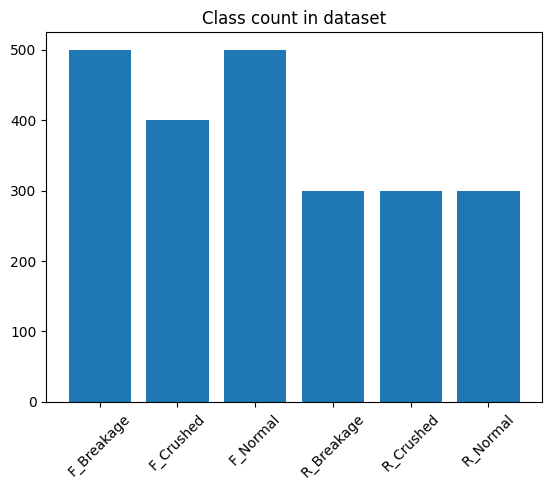

In [26]:


tf=transforms.Compose([
    ToTensor(),
    Resize(size=[224,224])
])

#************* Load phase
#Load the raw dataset and create data loaders
raw_dataset=datasets.ImageFolder(root="Download files\\dataset",transform=tf)

#************ Data imbalance inspection phase
#Creating the class dictionary
class_dict={}
for key,name in zip(range(len(raw_dataset.classes)),raw_dataset.classes):
    class_dict[key]=name


#Counting labels
label_list=[label for _,label in raw_dataset.samples] #Concatenate the label list
counts=collections.Counter(label_list)

#Plotting classes
plt.bar(x=class_dict.keys(),height=counts.values())
plt.xticks(list(class_dict.keys()),class_dict.values(),rotation=45)
plt.title("Class count in dataset")
plt.show()


In [27]:
#Split data into train_test
indexes=list(range(len(raw_dataset)))

train_idx,test_idx=train_test_split(indexes,test_size=0.3,shuffle=True,random_state=42)

#For data exploration only Train set is required
train_set=torch.utils.data.Subset(raw_dataset,train_idx)

b_size=64
torch.manual_seed(42)
np.random.seed(42)
train_loader=DataLoader(train_set,batch_size=b_size,shuffle=True)


In [28]:
#************** Summary
#Checking inputs
print("---------------------------------------")
print("Raw Dataset")
print(raw_dataset)
print("---------------------------------------")
print(f"Batches in train set: {len(train_loader)} --- Number of images in train set {len(train_loader.dataset)}")
print("---------------------------------------")
print("Class Dictionary:")
print(class_dict)

---------------------------------------
Raw Dataset
Dataset ImageFolder
    Number of datapoints: 2300
    Root location: Download files\dataset
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[224, 224], interpolation=bilinear, max_size=None, antialias=True)
           )
---------------------------------------
Batches in train set: 26 --- Number of images in train set 1610
---------------------------------------
Class Dictionary:
{0: 'F_Breakage', 1: 'F_Crushed', 2: 'F_Normal', 3: 'R_Breakage', 4: 'R_Crushed', 5: 'R_Normal'}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015907383..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.18968226..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0063890945..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.013214661..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01936713..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015907383..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05

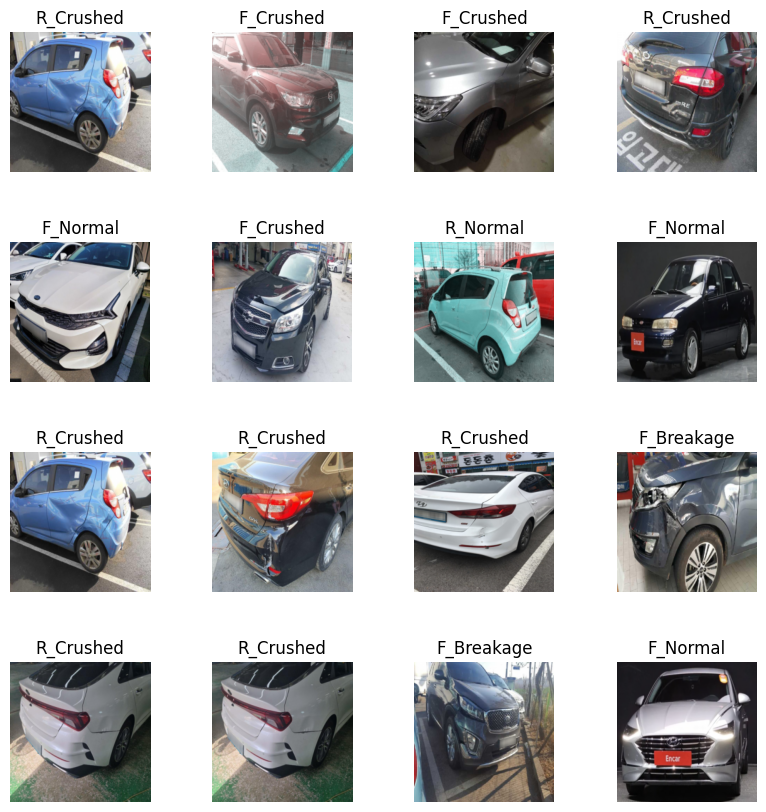

In [29]:
#Exploring some images of the train dataset

fig,axs=plt.subplots(4,4,figsize=(10,10))
plt.subplots_adjust(hspace=0.5)
for im_train,label_train in train_loader:
    for i in range(4):
        for j in range(4):
            idx=np.random.randint(0,im_train.size(0))
            im=im_train[idx]
            label=label_train[idx]
            axs[i,j].imshow(im.permute(1,2,0))
            axs[i,j].set_title(class_dict[label.item()])
            axs[i,j].axis("off")
    break            
plt.show()

## Data Normalization and re-importation

### Takeaways:
 * Mean and standard deviation is computed for each channel.
 * Input images are reimported using the mean and standard deviation to normalize.
 * Train (70%), validation(15%) and test (15%) sets are splitted from original data. Data augmentation is applied to train set, whereas validation and test are only reshaped and normalized.

In [30]:
#Getting normalization parammeters
#Get the normal and standard deviation of the training set to normalize images during training process
im_list=[] #List to concatenate all train images and compute mean and std
for im_train,_ in train_loader:
    im_list.append(im_train)

conc_data=torch.cat(im_list,dim=0)
mean_par=torch.mean(conc_data,dim=(0,2,3)) #Compute mean per rgb channel
std_par=torch.std(conc_data,dim=(0,2,3))   #Compute std per rgb channel

print(mean_par,std_par)

tensor([0.4451, 0.4411, 0.4429]) tensor([0.2675, 0.2663, 0.2674])


In [31]:
#Normalization parammeters are acquired
#The datasets are re imported with normalization and data augmentation
#However, data augmentation should only be applied to train loader

#Data augmentation is considered for train set
train_tranforms=Compose([
    transforms.Resize(size=[224,224]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_par,std=std_par)
])

#Only resize and normalization are applied to test set
test_tranforms=Compose([
    transforms.Resize(size=[224,224]),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_par,std=std_par)
])

#ReLoad the raw dataset and create data loaders
raw_dataset=datasets.ImageFolder(root="Download files\\dataset",transform=tf)

#To apply the respective transformation to train and test subset we have to use a subset approach
indexes=list(range(len(raw_dataset)))

train_idx,test_val_idx=train_test_split(indexes,test_size=0.3,shuffle=True,random_state=42)
test_idx,val_idx=train_test_split(test_val_idx,test_size=0.5,shuffle=False,random_state=42)


train_set=torch.utils.data.Subset(raw_dataset,train_idx)
test_set=torch.utils.data.Subset(raw_dataset,test_idx)
val_set=torch.utils.data.Subset(raw_dataset,val_idx)

#Overwrite test and validation set transform
train_set.dataset.transform=train_tranforms
test_set.dataset.transform=test_tranforms
val_set.dataset.transform=test_tranforms


train_loader=DataLoader(train_set,batch_size=b_size,shuffle=True)
test_loader=DataLoader(test_set,batch_size=b_size,shuffle=False)
val_loader=DataLoader(val_set,batch_size=b_size,shuffle=False)


#Recheck train and test data loaders
print("---------------------------------------")
print(f"Train set: Images {len(train_loader.dataset)} | Batches {len(train_loader)}")
print(f"Validation set: Images {len(val_loader.dataset)} | Batches {len(val_loader)}")
print(f"Test set: Images {len(test_loader.dataset)} | Batches {len(test_loader)}")
print("---------------------------------------")



---------------------------------------
Train set: Images 1610 | Batches 26
Validation set: Images 345 | Batches 6
Test set: Images 345 | Batches 6
---------------------------------------


# Model Training and validation

This section implements different models  with the goal of achieving at least 70% accuracy. 

The proposed options are:

* CNN with no regularization (Used as baseline).
* CNN with regularization to try correcting overfitting.
* Pretrained models, specifically Efficientnet and Resnet50 with modifications for the fully connected network.

All models where trained with early early stopping to prevent overfitting, and considering Cross Entropy as loss function. Final performance is assessed on the test set.

### TakeAways
* The baseline CNN (no regularization) achieved 48% accuracy, showing signs of severe overfitting.
* The regularized CNN improved slightly to 51% accuracy, despite applying dropout, batch normalization, and aggressive Adam optimizer settings (low learning rate, high weight decay, and tuned betas).
* Pretrained models outperformed the CNNs significantly:
    * EfficientNet reached 69%
    * ResNet50 reached 75%
* Finally, Optuna was used to tune hyperparameters for ResNet50, further improving accuracy to 80%

## CNN with no regularization
As first step a CNN with no regularization is applied

### Architecture
***
Size as (Channels,Height,With), Input: 3,224,224

**--------------- Convolutional Network -----------------**

**Layer1:**

* Conv2d 32 channels with padding,kernell 3x3 -> 32,224,224
* ReLU
* MaxPool2d with kernell 2x2 and stride of 2 -> 32,112,112

**Layer2:**
* Conv2d 64 channels with padding,kernell 3x3-> 64,112,112
* ReLU
* MaxPool2d with kernell 2x2 and stride of 2 -> 64,56,56

**Layer3:**
* Conv2d 128 channels with padding,kernell 3x3 -> 128,56,56
* ReLU
* MaxPool2d with kernell 2x2 and stride of 2 -> 128,28,28


**--------------- Fully connected Network -----------------**

**Layer1:**
* Flatten -> 128*28*28
* Linear -> 128*28*28 to 256
* ReLu()

**Layer2:**
* Linear -> 256 to 64
* ReLu()

**Layer3:**
* Linear -> 64 to 32
* ReLu()

**Layer4:**
* Linear -> 32 to 6


### Neural class definition

In [ ]:
#Creating the CNN class

class cnn_no_reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn=nn.Sequential(

            #Layer 1
            nn.Conv2d(3,32,kernel_size=(3,3),padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,kernel_size=2), #128

            #layer 2
            nn.Conv2d(32,64,kernel_size=(3,3),padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,kernel_size=2), #64

            nn.Conv2d(64,128,kernel_size=(3,3),padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,kernel_size=2), #32
        )

        self.fcn=nn.Sequential(
            #Layer1
            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),

            #Layer3
            nn.Linear(256,64),
            nn.ReLU(),

            #Layer3
            nn.Linear(64,32),
            nn.ReLU(),

            #Layer4
            nn.Linear(32,6),
        )

    def forward(self,X):
        output_cnn=self.cnn(X) #Run CNN
        return self.fcn(output_cnn)

### Training phase

In [33]:
# Creating the training
def training_model(train_loader,validation_loader,model,optimizer,loss_fun,epochs,patience):
    '''
    Description:
        Trains the model over a train loader in a number of epochs using and optimizer and a loss function with a patience criteria for early stopagge
        Training is carried on with a mini batch approach

    Inputs
        train_loader:       Train loader that contains batches with images and labels for training
        validation_loader:  Validation loader that contains batches with images and labels for validation
        model:              Neural network object to train
        optimizer:          Defined pytorch object as optimizer
        loss_fun:           loss function used as optimization criterion
        epochs:             Number of epochs for training
        patience:           Number of epochs to wait for improvement in validation loss before early stoppage    
    
    Returns
        train_loss:         Average train loss per epoch
        validation_loss:    Average validation loss per epoch
    '''

    #Lists for storing train and validation loss
    train_loss,val_loss=[],[]
    best_loss,epoch_count,best_epoch=1e5,0,0 #Initial loss and epoch set for early stopagge criteria
                                             #Initial loss is set to a very large loss as starting point
    for epoch in range(epochs):
        model.train() #Set model to train mode
        total_train_loss,total_val_loss=0,0 #store cumulative loss of minibatch for train an validation

        #************************* Weights update phase
        for im_train,label_train in train_loader:
            
            #Prediction
            im_train,label_train=im_train.to(device),label_train.to(device)
            train_pred=model(im_train)             #Get the batch of images for training
            loss=loss_fun(train_pred,label_train)  #Compute loss between prediction and ground truth
            total_train_loss+=loss.item()          #Append minibatch loss

            #Back propagation
            optimizer.zero_grad()                  #Reset gradients
            loss.backward()                        #Back propagation
            optimizer.step()                       #Update network params with gradient descent

        train_loss.append(total_train_loss/len(train_loader))     #Store average train loss for epoch

        #************************* early stopagge criteria applied on validation set
        
        with torch.no_grad(): #Disables back propagation
            for im_val,label_val in validation_loader:
                #Minibatch prediction and lost computation for validation set
                im_val,label_val=im_val.to(device),label_val.to(device)
                val_pred=model(im_val)
                loss_val=loss_fun(val_pred,label_val)
                total_val_loss+=loss_val.item()

            val_loss.append(total_val_loss/len(validation_loader))  #Average validation loss 

            if val_loss[-1]<best_loss:    #In case the loss value improves epochs counter for early stopagge is reset
                best_loss=val_loss[-1]
                best_epoch=epoch
                best_state_dict = copy.deepcopy(model.state_dict())
                epoch_count=0                
            else:                           #Else counter +1, if reaches to patience criteria stops
                epoch_count+=1               
                if epoch_count==patience:
                    model.load_state_dict(best_state_dict) #Return to best state in case of early stopagge
                    print(f"Early stopagge at epoch {best_epoch}/{epochs} ---- Train Loss {train_loss[best_epoch]:.4f} ---- Validation Loss {val_loss[best_epoch]:.4f}")
                    break
        
        print(f"Epoch ({epoch+1}/{epochs}) ---- Train Loss {train_loss[-1]:.4f} ---- Validation Loss {val_loss[-1]:.4f}")
        
                    
    return train_loss,val_loss,best_epoch

model=cnn_no_reg().to(device)
l_rate=0.001
epochs=100
patience=5
optimizer=torch.optim.AdamW(model.parameters(),lr=l_rate)
loss_fun=nn.CrossEntropyLoss()


train_loss,val_loss,best_epoch=training_model(train_loader,val_loader,model,optimizer,loss_fun,epochs,patience)

Epoch (1/100) ---- Train Loss 1.7358 ---- Validation Loss 1.5514
Epoch (2/100) ---- Train Loss 1.4169 ---- Validation Loss 1.4187
Epoch (3/100) ---- Train Loss 1.2430 ---- Validation Loss 1.4012
Epoch (4/100) ---- Train Loss 1.1328 ---- Validation Loss 1.2263
Epoch (5/100) ---- Train Loss 0.9765 ---- Validation Loss 1.1980
Epoch (6/100) ---- Train Loss 0.7928 ---- Validation Loss 1.3119
Epoch (7/100) ---- Train Loss 0.5803 ---- Validation Loss 1.4034
Epoch (8/100) ---- Train Loss 0.3268 ---- Validation Loss 1.5027
Epoch (9/100) ---- Train Loss 0.1592 ---- Validation Loss 2.3345
Early stopagge at epoch 4/100 ---- Train Loss 0.9765 ---- Validation Loss 1.1980


### Validation Phase

-------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.55      0.22      0.31        82
           1       0.31      0.83      0.45        54
           2       0.98      0.68      0.80        71
           3       0.31      0.23      0.26        53
           4       0.41      0.44      0.42        48
           5       0.71      0.54      0.62        37

    accuracy                           0.48       345
   macro avg       0.54      0.49      0.48       345
weighted avg       0.56      0.48      0.47       345

-------------------
Accuracy: 
 47.54
-------------------
Confussion Matrix:


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'F_Breakage'),
  Text(1, 0, 'F_Crushed'),
  Text(2, 0, 'F_Normal'),
  Text(3, 0, 'R_Breakage'),
  Text(4, 0, 'R_Crushed'),
  Text(5, 0, 'R_Normal')])

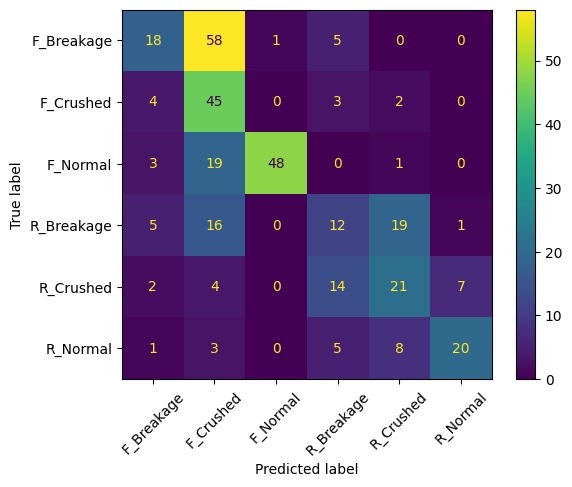

In [34]:
def model_validation(model,test_loader):
    '''
    Description:
        Function to evaluate the model on a given test loader.
    
    Inputs
        model: model to evaluate
        test_loader: Loader with test images and labels

    Returns
        acc_test:   Accuracy computed on test set
        cm_test:    Confussion matrix of the model predictions on test set
        report:     classification report
    '''
    
    #Initialize rights and counts
    total_rights=0
    total_counts=0
    
    #Lists to store predictions and ground truth labels
    pred_labels,test_labels=[],[]

    #Set the model to evaluation mode
    model.eval()
    with torch.no_grad():
        for im_test,lab_test in test_loader:
            im_test,lab_test=im_test.to(device),lab_test.to(device)
            model_output=model(im_test)                             #Output prediction
            _,class_predictd=torch.max(model_output,dim=1)       #Get class predicted

            rights=(class_predictd.long()==lab_test).sum()         #Count right predictions
            total_rights+=rights.item()                             #Acumulate rights
            total_counts+=len(lab_test)                             #Acumulate counts

            pred_labels.append(class_predictd.cpu())              #Append lists of predictions and labels
            test_labels.append(lab_test.cpu())

    pred_labels=torch.cat(pred_labels).numpy()
    test_labels=torch.cat(test_labels).numpy()

    #Computing outputs for accuracy, classification report and confussion matrix
    acc_test=round(total_rights*100/total_counts,2)
    report=classification_report(test_labels,pred_labels)
    cm_test=confusion_matrix(test_labels,pred_labels)

    return  acc_test,report, cm_test

acc_test,report, cm_test = model_validation(model,test_loader)

print("-------------------")
print(f"Classification report: \n {report}")
print("-------------------")
print(f"Accuracy: \n {acc_test}")
print("-------------------")
print(f"Confussion Matrix:")

disp=ConfusionMatrixDisplay(cm_test,display_labels=class_dict.values());
disp.plot();
plt.xticks(rotation=45)

## With dropout and batch normalization

As Second step a CNN with regularization is applied

### Architecture
***
Size as (Channels,Height,With), Input: 3,224,224

**--------------- Convolutional Network -----------------**

**Layer1:**

* Conv2d 32 channels with padding,kernell 3x3 -> 32,224,224
* ReLU
* MaxPool2d with kernell 2x2 and stride of 2 -> 32,112,112

**Layer2:**
* Conv2d 64 channels with padding,kernell 3x3-> 64,112,112
* ReLU
* MaxPool2d with kernell 2x2 and stride of 2 -> 64,56,56

**Layer3:**
* Conv2d 128 channels with padding,kernell 3x3 -> 128,56,56
* ReLU
* MaxPool2d with kernell 2x2 and stride of 2 -> 128,28,28
* AdaptiveAvgPool2d to reduce size.


**--------------- Fully connected Network -----------------**

**Layer1:**
* Flatten -> 128
* Linear -> 128 to 64
* Batch Normalization
* ReLu()
* Dropout (P=0.5)

**Layer2:**
* Linear -> 64 to 32
* Batch Normalization
* ReLu()
* Dropout (P=0.5)

**Layer3:**
* Linear -> 32 to 6

In [ ]:
#Creating the CNN class

class cnn_reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn=nn.Sequential(

            #Layer 1
            nn.Conv2d(3,32,kernel_size=(3,3),padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,kernel_size=2), #128

            #layer 2
            nn.Conv2d(32,64,kernel_size=(3,3),padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,kernel_size=2), #64

            #layer 3
            nn.Conv2d(64,128,kernel_size=(3,3),padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(stride=2,kernel_size=2), #64           
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fcn=nn.Sequential(
            #Layer1
            nn.Flatten(),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            #Layer2
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            #Layer3
            nn.Linear(32,6),
        )

    def forward(self,X):
        output_cnn=self.cnn(X) #Run CNN
        return self.fcn(output_cnn)

In [36]:
model_reg=cnn_reg().to(device)
l_rate=0.001
epochs=100
patience=5
optimizer=torch.optim.AdamW(model_reg.parameters(),lr=l_rate,weight_decay=1e-3,betas=(0.9, 0.99))
loss_fun=nn.CrossEntropyLoss()
train_loss_reg,val_loss_reg,best_epoch_reg=training_model(train_loader,val_loader,model_reg,optimizer,loss_fun,epochs,patience)

Epoch (1/100) ---- Train Loss 1.7500 ---- Validation Loss 1.7843
Epoch (2/100) ---- Train Loss 1.6972 ---- Validation Loss 1.6931
Epoch (3/100) ---- Train Loss 1.6540 ---- Validation Loss 1.6931
Epoch (4/100) ---- Train Loss 1.6270 ---- Validation Loss 1.6556
Epoch (5/100) ---- Train Loss 1.5961 ---- Validation Loss 1.5959
Epoch (6/100) ---- Train Loss 1.5324 ---- Validation Loss 1.5675
Epoch (7/100) ---- Train Loss 1.4889 ---- Validation Loss 1.4914
Epoch (8/100) ---- Train Loss 1.4433 ---- Validation Loss 1.4477
Epoch (9/100) ---- Train Loss 1.3799 ---- Validation Loss 1.3392
Epoch (10/100) ---- Train Loss 1.3549 ---- Validation Loss 1.3368
Epoch (11/100) ---- Train Loss 1.3138 ---- Validation Loss 1.3271
Epoch (12/100) ---- Train Loss 1.2784 ---- Validation Loss 1.3079
Epoch (13/100) ---- Train Loss 1.2283 ---- Validation Loss 1.2779
Epoch (14/100) ---- Train Loss 1.2100 ---- Validation Loss 1.2537
Epoch (15/100) ---- Train Loss 1.1733 ---- Validation Loss 1.2334
Epoch (16/100) ----

-------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.52      0.74      0.61        82
           1       0.30      0.20      0.24        54
           2       0.77      0.65      0.70        71
           3       0.50      0.23      0.31        53
           4       0.40      0.71      0.51        48
           5       0.52      0.30      0.38        37

    accuracy                           0.51       345
   macro avg       0.50      0.47      0.46       345
weighted avg       0.52      0.51      0.49       345

-------------------
Accuracy: 
 50.72
-------------------
Confussion Matrix:


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'F_Breakage'),
  Text(1, 0, 'F_Crushed'),
  Text(2, 0, 'F_Normal'),
  Text(3, 0, 'R_Breakage'),
  Text(4, 0, 'R_Crushed'),
  Text(5, 0, 'R_Normal')])

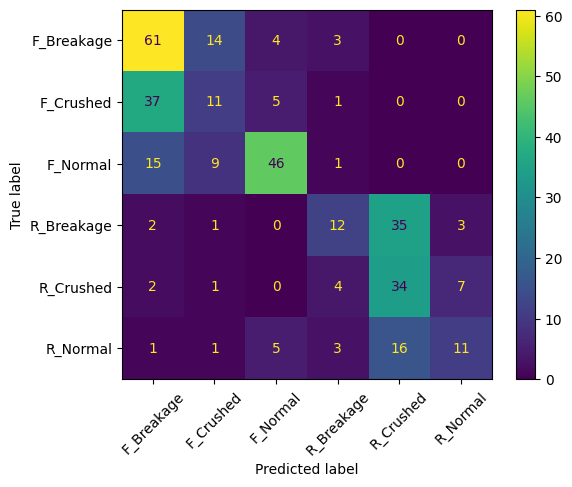

In [37]:
acc_test_reg,report_reg, cm_test_reg = model_validation(model_reg,test_loader)

print("-------------------")
print(f"Classification report: \n {report_reg}")
print("-------------------")
print(f"Accuracy: \n {acc_test_reg}")
print("-------------------")
print(f"Confussion Matrix:")

disp=ConfusionMatrixDisplay(cm_test_reg,display_labels=class_dict.values());
disp.plot();
plt.xticks(rotation=45)

## Transfer Learning - EfficientNet

### Neural Class Definition

In [38]:
class pret_neural(nn.Module):
    def __init__(self,drop_l1=0.5,drop_l2=0.5):
        super().__init__()
        self.pret_model=models.efficientnet_b0(weights="DEFAULT")
        
        #Freeze predefined parameters
        for param in self.pret_model.parameters():
            param.requires_grad=False   

        n_layers=self.pret_model.classifier[1].in_features#Number of input layers
        self.pret_model.classifier[1]=nn.Sequential(
                        #Layer 1
                        nn.Linear(n_layers,256),
                        nn.BatchNorm1d(256),
                        nn.ReLU(),
                        nn.Dropout(p=drop_l1),

                        #Layer 2
                        nn.Linear(256,64),
                        nn.BatchNorm1d(64),
                        nn.ReLU(),
                        nn.Dropout(p=drop_l2),

                        #Layer 3
                        nn.Linear(64,6)
                        )
        
    def forward(self,X):
        return self.pret_model(X)

### Training Phase

In [39]:
pret_model=pret_neural(0.5,0.5)
pret_model.to(device)
l_rate=0.001
epochs=100
patience=5
optimizer=torch.optim.AdamW(filter(lambda p: p.requires_grad,pret_model.parameters()),lr=l_rate,weight_decay=1e-3,betas=(0.9, 0.99))
loss_fun=nn.CrossEntropyLoss()
train_loss_pret,val_loss_pret,best_epoch_pret=training_model(train_loader,val_loader,pret_model,optimizer,loss_fun,epochs,patience)

Epoch (1/100) ---- Train Loss 1.5305 ---- Validation Loss 1.3219
Epoch (2/100) ---- Train Loss 1.1522 ---- Validation Loss 1.1356
Epoch (3/100) ---- Train Loss 1.0183 ---- Validation Loss 1.0832
Epoch (4/100) ---- Train Loss 0.8890 ---- Validation Loss 1.0246
Epoch (5/100) ---- Train Loss 0.8032 ---- Validation Loss 1.0026
Epoch (6/100) ---- Train Loss 0.7353 ---- Validation Loss 0.9729
Epoch (7/100) ---- Train Loss 0.7019 ---- Validation Loss 0.9839
Epoch (8/100) ---- Train Loss 0.6588 ---- Validation Loss 1.0124
Epoch (9/100) ---- Train Loss 0.6306 ---- Validation Loss 0.9796
Epoch (10/100) ---- Train Loss 0.6257 ---- Validation Loss 0.9586
Epoch (11/100) ---- Train Loss 0.5785 ---- Validation Loss 0.9779
Epoch (12/100) ---- Train Loss 0.5800 ---- Validation Loss 1.0536
Epoch (13/100) ---- Train Loss 0.5424 ---- Validation Loss 1.0180
Epoch (14/100) ---- Train Loss 0.5001 ---- Validation Loss 1.0181
Early stopagge at epoch 9/100 ---- Train Loss 0.6257 ---- Validation Loss 0.9586


### Validation Phase

-------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.71      0.70      0.70        82
           1       0.58      0.65      0.61        54
           2       0.84      0.79      0.81        71
           3       0.61      0.66      0.64        53
           4       0.67      0.58      0.62        48
           5       0.67      0.70      0.68        37

    accuracy                           0.69       345
   macro avg       0.68      0.68      0.68       345
weighted avg       0.69      0.69      0.69       345

-------------------
Accuracy: 
 68.7
-------------------
Confussion Matrix:


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'F_Breakage'),
  Text(1, 0, 'F_Crushed'),
  Text(2, 0, 'F_Normal'),
  Text(3, 0, 'R_Breakage'),
  Text(4, 0, 'R_Crushed'),
  Text(5, 0, 'R_Normal')])

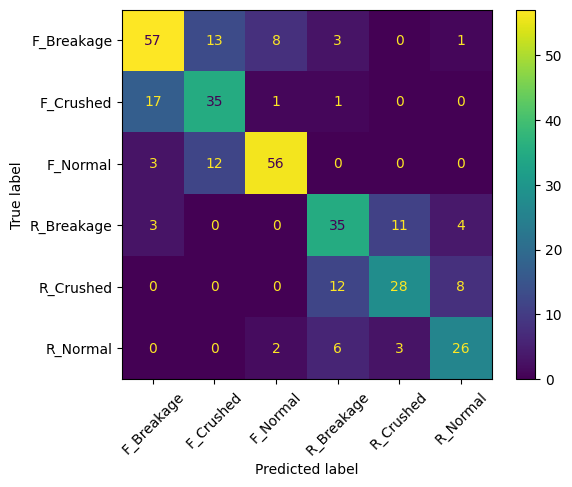

In [40]:
acc_test_pret,report_pret, cm_test_pret = model_validation(pret_model,test_loader)

print("-------------------")
print(f"Classification report: \n {report_pret}")
print("-------------------")
print(f"Accuracy: \n {acc_test_pret}")
print("-------------------")
print(f"Confussion Matrix:")

disp=ConfusionMatrixDisplay(cm_test_pret,display_labels=class_dict.values());
disp.plot();
plt.xticks(rotation=45)

## Transfer Learning - Resnet

### Neural class definition

In [41]:
class pret_neural_resnet(nn.Module):
    def __init__(self,drop_l1=0.5,drop_l2=0.5):
        super().__init__()
        self.pret_model=models.resnet50(weights="DEFAULT")
        
        #Freeze predefined parameters
        for param in self.pret_model.parameters():
            param.requires_grad=False  

        #Unfreeze layer 4 
        for param in self.pret_model.layer4.parameters():
            param.requires_grad=True  

        n_layers=self.pret_model.fc.in_features#Number of input layers
        self.pret_model.fc=nn.Sequential(
                        #Layer 1
                        nn.Linear(n_layers,256),
                        nn.BatchNorm1d(256),
                        nn.ReLU(),
                        nn.Dropout(p=drop_l1),

                        #Layer 2
                        nn.Linear(256,64),
                        nn.BatchNorm1d(64),
                        nn.ReLU(),
                        nn.Dropout(p=drop_l2),

                        #Layer 3
                        nn.Linear(64,6)
                        )
        
    def forward(self,X):
        return self.pret_model(X)

### Training phase

In [44]:
pret_model_resnet=pret_neural_resnet(0.5,0.5)
pret_model_resnet.to(device)
l_rate=0.001
epochs=100
patience=5
optimizer=torch.optim.AdamW(filter(lambda p: p.requires_grad,pret_model_resnet.parameters()),lr=l_rate,weight_decay=1e-3,betas=(0.9, 0.99))
loss_fun=nn.CrossEntropyLoss()
train_loss_pret,val_loss_pret,best_epoch_pret=training_model(train_loader,val_loader,pret_model_resnet,optimizer,loss_fun,epochs,patience)

Epoch (1/100) ---- Train Loss 1.2894 ---- Validation Loss 0.9221
Epoch (2/100) ---- Train Loss 0.7591 ---- Validation Loss 0.7316
Epoch (3/100) ---- Train Loss 0.4487 ---- Validation Loss 0.7268
Epoch (4/100) ---- Train Loss 0.3008 ---- Validation Loss 0.7465
Epoch (5/100) ---- Train Loss 0.2312 ---- Validation Loss 0.6943
Epoch (6/100) ---- Train Loss 0.2259 ---- Validation Loss 0.7640
Epoch (7/100) ---- Train Loss 0.2092 ---- Validation Loss 0.7459
Epoch (8/100) ---- Train Loss 0.2290 ---- Validation Loss 0.7231
Epoch (9/100) ---- Train Loss 0.1756 ---- Validation Loss 0.7985
Early stopagge at epoch 4/100 ---- Train Loss 0.2312 ---- Validation Loss 0.6943


### Validation Phase

-------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.89      0.78      0.83        82
           1       0.61      0.72      0.66        54
           2       0.88      0.89      0.88        71
           3       0.80      0.66      0.72        53
           4       0.67      0.46      0.54        48
           5       0.57      0.92      0.70        37

    accuracy                           0.74       345
   macro avg       0.73      0.74      0.72       345
weighted avg       0.76      0.74      0.74       345

-------------------
Accuracy: 
 74.49
-------------------
Confussion Matrix:


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'F_Breakage'),
  Text(1, 0, 'F_Crushed'),
  Text(2, 0, 'F_Normal'),
  Text(3, 0, 'R_Breakage'),
  Text(4, 0, 'R_Crushed'),
  Text(5, 0, 'R_Normal')])

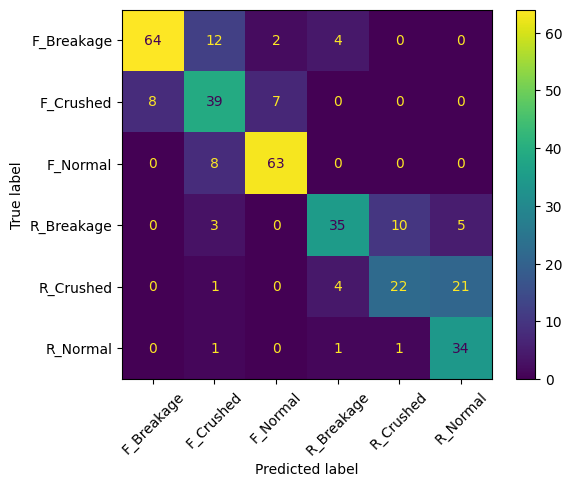

In [45]:
acc_test_resnet,report_resnet, cm_test_resnet = model_validation(pret_model_resnet,test_loader)

print("-------------------")
print(f"Classification report: \n {report_resnet}")
print("-------------------")
print(f"Accuracy: \n {acc_test_resnet}")
print("-------------------")
print(f"Confussion Matrix:")

disp=ConfusionMatrixDisplay(cm_test_resnet,display_labels=class_dict.values());
disp.plot();
plt.xticks(rotation=45)

In [46]:
#Saving the parammeters from resnet model

torch.save(pret_model_resnet.state_dict(), "resnet_base.pth")

## Resnet Optimization with Optuna

### Case study definition

In [68]:
def max_acc(trial):
    '''
    Description
        Function to optimize hyparameters based on a optuna's case study using accuracy on validation set
    
    Inputs
        trial: Number of trials considered
        model: Model used as study

    Output
        accuracy: Maximized accuracy on validation set
    '''
    #Creating space study
    l_rate=trial.suggest_float("l_rate",1e-5,1e-2,log=True) # Learning rate range
    w_decay=trial.suggest_float("w_decay",1e-6,1e-2,log=True) # Weight decay range
    drop_l1=trial.suggest_float("drop_l1",0.3,0.8,step=0.05) # Drop probability for layer 1
    drop_l2=trial.suggest_float("drop_l2",0.3,0.8,step=0.05) # Drop probability for layer 2


    #********************************** Model definition

    best_model=pret_neural_resnet(drop_l1,drop_l2) #Overwrite FC of pretrained model
    best_model.load_state_dict(torch.load("resnet_base.pth"))  #Reloading the pretrained base to improve optimization
    best_model.to(device)

    #Setting hyperparameters
    optimizer=torch.optim.Adam(filter(lambda p: p.requires_grad,best_model.parameters()),lr=l_rate,weight_decay=w_decay)
    patience=5
    epochs=50

    #Train and validation
    training_model(train_loader,val_loader,best_model,optimizer,loss_fun,epochs,patience)    
    accuracy,_, _ = model_validation(best_model,val_loader)

    #Progress report
    trial.report(accuracy, step=epochs)

    #Early prune if needed
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    
    #Tracking
    trial.set_user_attr("accuracy", accuracy)

    #Save the best model
    if len(trial.study.best_trials) == 0 or accuracy > trial.study.best_value:
        model_path = f"best_model_trial_{trial.number}.pth"
        torch.save(best_model.state_dict(), model_path)
        trial.set_user_attr("model_path", model_path)

    return accuracy

    
study=optuna.create_study(direction="maximize")  #Creating study case to maximize accuracy

#call the function to optimize
study.optimize(max_acc, n_trials=10, catch=(optuna.exceptions.TrialPruned,))



[I 2025-04-13 19:50:20,527] A new study created in memory with name: no-name-0074773d-68a5-4277-af09-24053d6b1ac0


Epoch (1/50) ---- Train Loss 0.8088 ---- Validation Loss 0.7563
Epoch (2/50) ---- Train Loss 0.5119 ---- Validation Loss 0.6987
Epoch (3/50) ---- Train Loss 0.3379 ---- Validation Loss 0.6807
Epoch (4/50) ---- Train Loss 0.2598 ---- Validation Loss 0.7955
Epoch (5/50) ---- Train Loss 0.2666 ---- Validation Loss 0.7602
Epoch (6/50) ---- Train Loss 0.3340 ---- Validation Loss 0.7286
Epoch (7/50) ---- Train Loss 0.2904 ---- Validation Loss 0.8007
Early stopagge at epoch 2/50 ---- Train Loss 0.3379 ---- Validation Loss 0.6807


[I 2025-04-13 20:14:13,819] Trial 0 finished with value: 77.1 and parameters: {'l_rate': 0.005155195262118712, 'w_decay': 0.00010695591604039035, 'drop_l1': 0.65, 'drop_l2': 0.55}. Best is trial 0 with value: 77.1.


Epoch (1/50) ---- Train Loss 0.1165 ---- Validation Loss 0.6826
Epoch (2/50) ---- Train Loss 0.1107 ---- Validation Loss 0.6528
Epoch (3/50) ---- Train Loss 0.0907 ---- Validation Loss 0.6480
Epoch (4/50) ---- Train Loss 0.0865 ---- Validation Loss 0.6260
Epoch (5/50) ---- Train Loss 0.0866 ---- Validation Loss 0.6195
Epoch (6/50) ---- Train Loss 0.0752 ---- Validation Loss 0.6705
Epoch (7/50) ---- Train Loss 0.0864 ---- Validation Loss 0.6603
Epoch (8/50) ---- Train Loss 0.0715 ---- Validation Loss 0.6769
Epoch (9/50) ---- Train Loss 0.0665 ---- Validation Loss 0.7181
Early stopagge at epoch 4/50 ---- Train Loss 0.0866 ---- Validation Loss 0.6195


[I 2025-04-13 20:38:24,084] Trial 1 finished with value: 80.58 and parameters: {'l_rate': 5.245648068955353e-05, 'w_decay': 1.4914952838618258e-05, 'drop_l1': 0.5, 'drop_l2': 0.35}. Best is trial 1 with value: 80.58.


...

[I 2025-04-13 23:50:01,748] Trial 7 pruned. 


Epoch (1/50) ---- Train Loss 1.0096 ---- Validation Loss 0.7436
Epoch (2/50) ---- Train Loss 0.6834 ---- Validation Loss 0.7172
Epoch (3/50) ---- Train Loss 0.4963 ---- Validation Loss 0.7842
Epoch (4/50) ---- Train Loss 0.3539 ---- Validation Loss 0.7641
Epoch (5/50) ---- Train Loss 0.3419 ---- Validation Loss 0.8534
Epoch (6/50) ---- Train Loss 0.2893 ---- Validation Loss 0.8895
Early stopagge at epoch 1/50 ---- Train Loss 0.6834 ---- Validation Loss 0.7172


[I 2025-04-14 00:07:42,187] Trial 8 pruned. 


Epoch (1/50) ---- Train Loss 0.1315 ---- Validation Loss 0.6366
Epoch (2/50) ---- Train Loss 0.1105 ---- Validation Loss 0.6524
Epoch (3/50) ---- Train Loss 0.1246 ---- Validation Loss 0.7078
Epoch (4/50) ---- Train Loss 0.0992 ---- Validation Loss 0.6948
Epoch (5/50) ---- Train Loss 0.1165 ---- Validation Loss 0.7217
Early stopagge at epoch 0/50 ---- Train Loss 0.1315 ---- Validation Loss 0.6366


[I 2025-04-14 00:21:48,353] Trial 9 pruned. 


In [72]:
#Getting the best params
best_trial.params

{'l_rate': 0.0012950795362706186,
 'w_decay': 0.00027842983983650667,
 'drop_l1': 0.3,
 'drop_l2': 0.5}

In [69]:
#Load the best model
best_trial=study.best_trial
#Use the best parammeters of the best trial
best_model=pret_neural_resnet(best_trial.params["drop_l1"],best_trial.params["drop_l2"]) 
best_model.to(device)
best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))


<All keys matched successfully>

### Validation phase

-------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.90      0.79      0.84        82
           1       0.74      0.74      0.74        54
           2       0.81      0.90      0.85        71
           3       0.80      0.68      0.73        53
           4       0.56      0.62      0.59        48
           5       0.63      0.70      0.67        37

    accuracy                           0.76       345
   macro avg       0.74      0.74      0.74       345
weighted avg       0.77      0.76      0.76       345

-------------------
Accuracy: 
 75.65
-------------------
Confussion Matrix:


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'F_Breakage'),
  Text(1, 0, 'F_Crushed'),
  Text(2, 0, 'F_Normal'),
  Text(3, 0, 'R_Breakage'),
  Text(4, 0, 'R_Crushed'),
  Text(5, 0, 'R_Normal')])

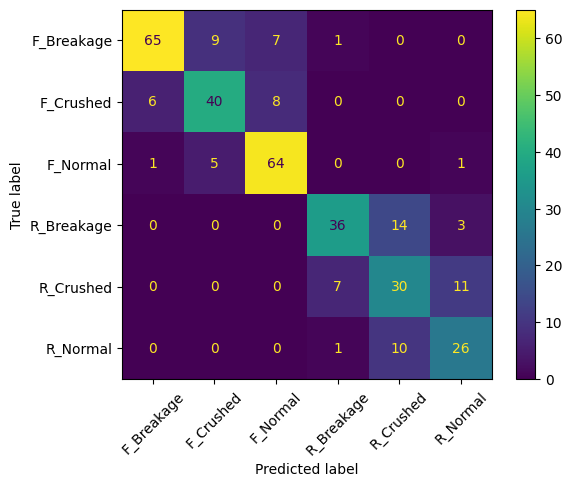

In [71]:
acc_test_pret_opt,report_pret_opt, cm_test_pret_opt = model_validation(best_model,test_loader)

print("-------------------")
print(f"Classification report: \n {report_pret_opt}")
print("-------------------")
print(f"Accuracy: \n {acc_test_pret_opt}")
print("-------------------")
print(f"Confussion Matrix:")

disp=ConfusionMatrixDisplay(cm_test_pret_opt,display_labels=class_dict.values());
disp.plot();
plt.xticks(rotation=45)